In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
df=pd.read_csv('/content/Final-project.csv')

In [ ]:
df.head(1)

,emission_id,year,facility_name,city,state,industry_sector,total_direct_emissions,CO2_emissions,CH4_emissions,N2O_emissions,total_major_ghg,emission_category,dominant_gas,CH4_share_pct,CO2_share_pct
0,1,2010,Adm Southern Cellulose Prod.In,Chattanooga,TN,Pulp And Paper,28791.592,28762.0,13.5,16.092,28791.592,Medium Emitter,Co2 Heavy,0.046889,99.89722


make sure there is no null values

In [ ]:
df.isnull().sum()

,0
emission_id,0
year,0
facility_name,0
city,0
state,0
industry_sector,0
total_direct_emissions,0
CO2_emissions,0
CH4_emissions,0
N2O_emissions,0


make sure there is no duplicated values

In [ ]:
df.duplicated().sum()

np.int64(0)

show some insights to prepare for predictions

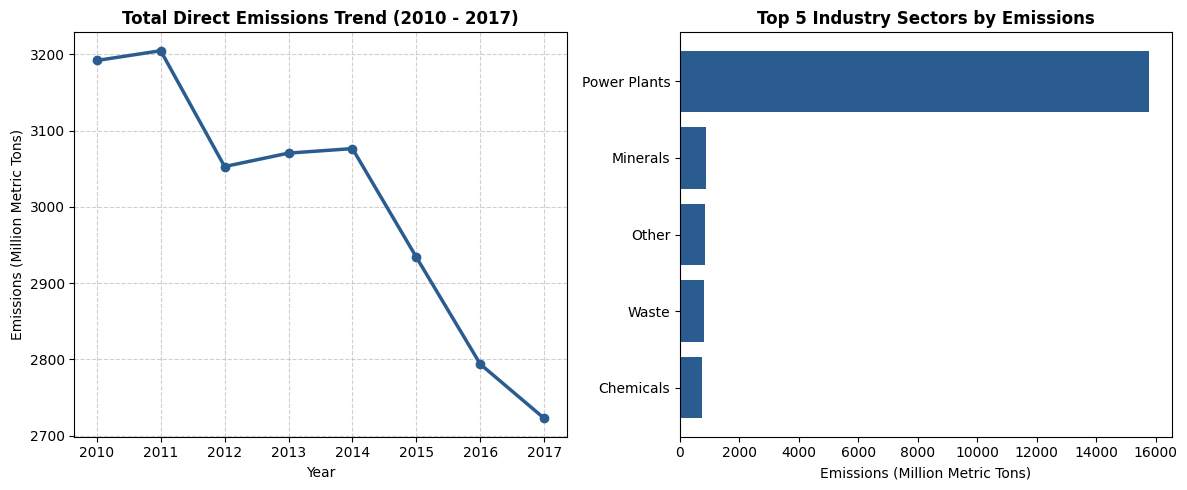

In [ ]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
yearly_emissions = (
    df.groupby('year')['total_direct_emissions'].sum() / 1e6
)
plt.plot(
    yearly_emissions.index,
    yearly_emissions.values,
    marker='o',
    color='#2b5c8f',
    linewidth=2.5,
)
plt.title(
    'Total Direct Emissions Trend (2010 - 2017)', fontweight='bold', fontsize=12
)
plt.xlabel('Year')
plt.ylabel('Emissions (Million Metric Tons)')
plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(1, 2, 2)
sector_emissions = (
    (df.groupby('industry_sector')['total_direct_emissions'].sum() / 1e6)
    .sort_values()
    .tail(5)
)
plt.barh(sector_emissions.index, sector_emissions.values, color='#2b5c8f')
plt.title('Top 5 Industry Sectors by Emissions', fontweight='bold', fontsize=12)
plt.xlabel('Emissions (Million Metric Tons)')

plt.tight_layout()
plt.show()

sorting data

In [ ]:
df['year'] = df['year'].astype(int)
df = df.sort_values(['facility_name', 'year']).reset_index(drop=True)

feature engineering

In [ ]:
df['lag_1'] = df.groupby('facility_name')['total_direct_emissions'].shift(1)
df['lag_2'] = df.groupby('facility_name')['total_direct_emissions'].shift(2)
df['rolling_mean_2'] = df.groupby('facility_name')['lag_1'].transform(
    lambda x: x.rolling(2, min_periods=1).mean()
)

encoding categorical feature

In [ ]:
categorical_cols = ['state', 'industry_sector','dominant_gas']
df_encoded = pd.get_dummies(
    df, columns=categorical_cols, drop_first=True, dummy_na=False
)

select features and target

In [ ]:
target = 'total_direct_emissions'
leak_cols = ['CO2_emissions', 'CH4_emissions', 'N2O_emissions', 'total_major_ghg', 'CH4_share_pct', 'CO2_share_pct', 'emission_category']
features = [
    col
    for col in df_encoded.columns
    if col not in ['year', 'facility_name', 'city', target] + leak_cols
]#target and features

see outliers

In [ ]:
Q1 = df['total_direct_emissions'].quantile(0.25)
Q3 = df['total_direct_emissions'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df['total_direct_emissions'] < lower_bound) | (df['total_direct_emissions'] > upper_bound)]

print(f"Lower Bound: {lower_bound:,.2f}")
print(f"Upper Bound: {upper_bound:,.2f}")
print(f"Number of Outliers: {len(outliers)}")
print(f"Percentage of Outliers: {(len(outliers) / len(df)) * 100:.2f}%")

Lower Bound: -193,236.99
Upper Bound: 406,069.73
Number of Outliers: 8791
Percentage of Outliers: 16.06%


train ,test & evaluate model

In [ ]:
train_df = df_encoded.dropna(subset=['lag_1', 'lag_2']).copy()
train_split = train_df[train_df['year'] <2015]
test_split = train_df[train_df['year'] >=2015]
X_train_eval, y_train_eval = train_split[features], train_split[target]
X_test_eval, y_test_eval = test_split[features], test_split[target]
eval_model = RandomForestRegressor(
    n_estimators=100, random_state=42
)
eval_model.fit(X_train_eval, y_train_eval)
preds_eval = eval_model.predict(X_test_eval)
mae = mean_absolute_error(y_test_eval, preds_eval)
rmse = mean_squared_error(y_test_eval, preds_eval) ** 0.5
r2 = r2_score(y_test_eval, preds_eval)
print('--- Model Evaluation Metrics (2017) ---')
print(f'MAE  : {mae:,.2f}')
print(f'RMSE : {rmse:,.2f}')
print(f'R2   : {r2:.4f}\n')

--- Model Evaluation Metrics (2017) ---
MAE  : 88,833.29
RMSE : 332,785.99
R2   : 0.9391



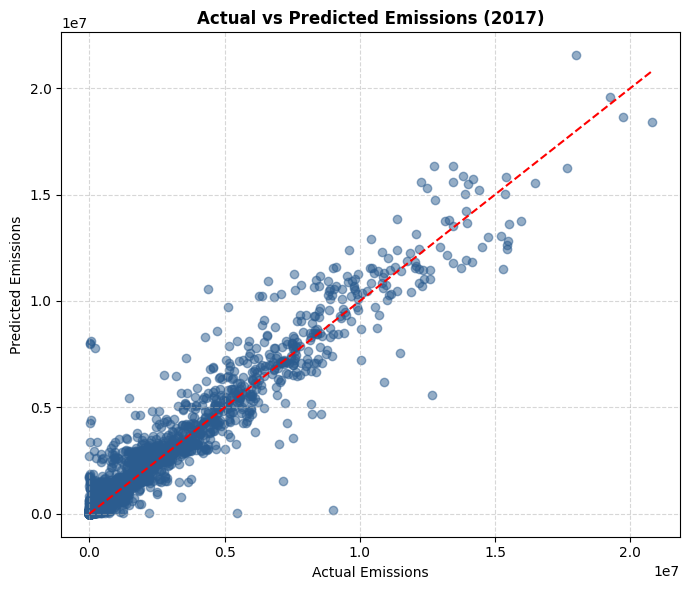

In [ ]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test_eval, preds_eval, alpha=0.5, color='#2b5c8f')
plt.plot(
    [y_test_eval.min(), y_test_eval.max()],
    [y_test_eval.min(), y_test_eval.max()],
    color='red', linestyle='--', linewidth=1.5
)
plt.title('Actual vs Predicted Emissions (2017)', fontweight='bold', fontsize=12)
plt.xlabel('Actual Emissions')
plt.ylabel('Predicted Emissions')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

apply random forest model

In [ ]:
final_model = RandomForestRegressor(
    n_estimators=100, random_state=42
)
final_model.fit(train_df[features], train_df[target])

RandomForestRegressor(random_state=42)

multi year recursvie forecasting

In [ ]:
n_years_to_forecast = 3
start_year = int(df['year'].max()) + 1
current_data = (
    df.sort_values('year').groupby('facility_name').last().reset_index()
)
all_forecasts = []
for i in range(n_years_to_forecast):
    forecast_year = start_year + i
    future_row = current_data.copy()
    future_row['year'] = forecast_year

    future_row['lag_2'] = future_row['lag_1']
    future_row['lag_1'] = future_row['total_direct_emissions']
    future_row['rolling_mean_2'] = future_row[['lag_1', 'lag_2']].mean(axis=1)
    future_row[['lag_1', 'lag_2', 'rolling_mean_2']] = future_row[
        ['lag_1', 'lag_2', 'rolling_mean_2']
    ].fillna(0)

    future_encoded = pd.get_dummies(
        future_row, columns=categorical_cols, drop_first=True, dummy_na=False
    )
    X_future = future_encoded.reindex(columns=features, fill_value=0)

    future_row['predicted_emissions'] = final_model.predict(X_future)
    all_forecasts.append(
        future_row[['facility_name', 'city', 'state', 'industry_sector',
                     'year', 'predicted_emissions']])
    current_data = future_row.copy()
    current_data['total_direct_emissions'] = current_data['predicted_emissions']

output = pd.concat(all_forecasts, ignore_index=True).sort_values(
    ['facility_name', 'year']
).reset_index(drop=True)

save the predictions to a csv file

In [ ]:
output.to_csv('predicted_emissions_2018_2020.csv', index=False)

show number of rows i made predictions on it

In [ ]:
print(f'Done! Saved predictions for {len(output)} facilities to predicted_emissions_2018.csv')

Done! Saved predictions for 25854 facilities to predicted_emissions_2018.csv


see the first 10 row of predicted data

In [ ]:
output.head(10)

,facility_name,city,state,industry_sector,year,predicted_emissions
0,121 Regional Disposal Facility,Melissa,TX,Waste,2018,219935.838980
1,121 Regional Disposal Facility,Melissa,TX,Waste,2019,220535.084540
2,121 Regional Disposal Facility,Melissa,TX,Waste,2020,217230.817954
3,15-18565/15-18662,Hazard,KY,Other,2018,181433.290353
4,15-18565/15-18662,Hazard,KY,Other,2019,130452.975660
5,15-18565/15-18662,Hazard,KY,Other,2020,121441.788357
6,15-19015,Hazard,KY,Other,2018,59978.266858
7,15-19015,Hazard,KY,Other,2019,54011.205595
8,15-19015,Hazard,KY,Other,2020,58399.594532
9,17Z Gas Plant - Chevron Usa Inc.,Mckittrick,CA,"Natural Gas And Natural Gas Liquids Suppliers,...",2018,24879.658300


see what is the most features that affect predictions

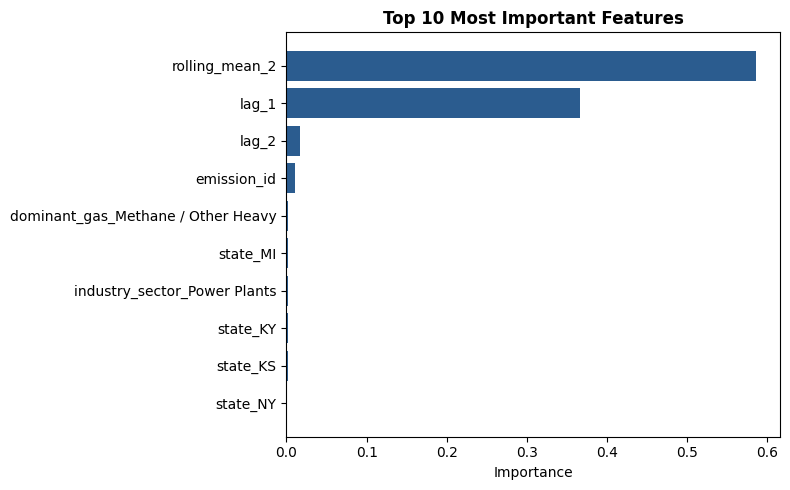

rolling_mean_2                        0.586393
lag_1                                 0.366324
lag_2                                 0.016528
emission_id                           0.010498
dominant_gas_Methane / Other Heavy    0.002097
state_MI                              0.001466
industry_sector_Power Plants          0.001459
state_KY                              0.001357
state_KS                              0.001334
state_NY                              0.001277
dtype: float64


In [ ]:
importances = pd.Series(final_model.feature_importances_, index=features)
top_importances = importances.sort_values(ascending=False).head(10)
plt.figure(figsize=(8, 5))
plt.barh(top_importances.index[::-1], top_importances.values[::-1], color='#2b5c8f')
plt.title('Top 10 Most Important Features', fontweight='bold', fontsize=12)
plt.xlabel('Importance')
plt.tight_layout()
plt.show()
print(top_importances)

top 10 lowest

/tmp/ipykernel_6147/2118307296.py:6: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


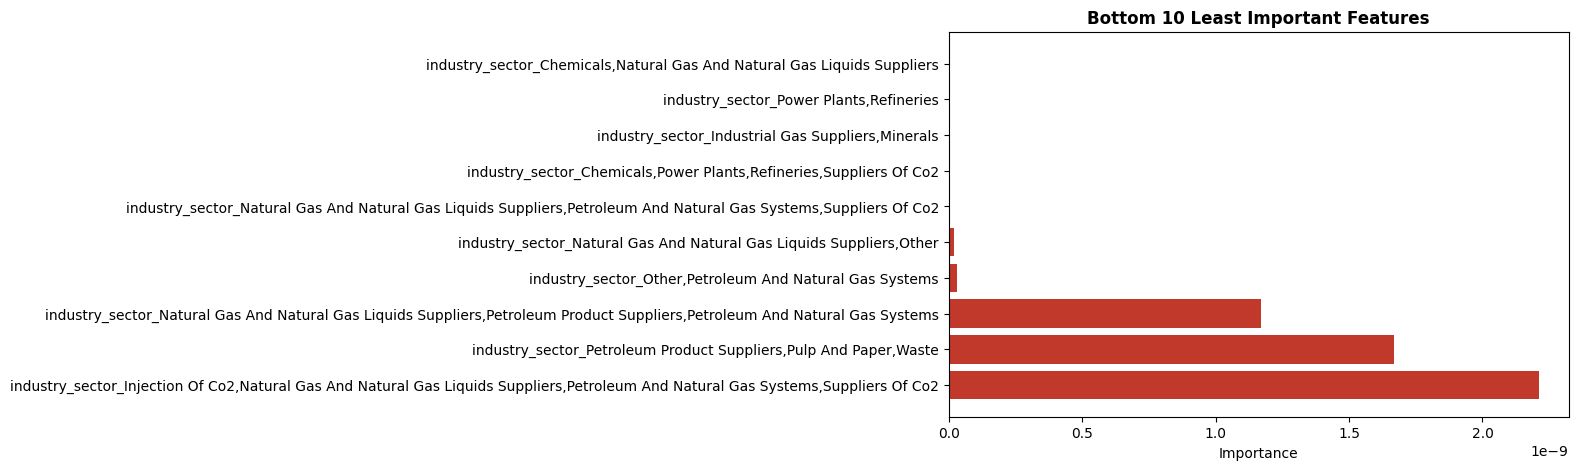

industry_sector_Chemicals,Natural Gas And Natural Gas Liquids Suppliers                                                              0.000000e+00
industry_sector_Power Plants,Refineries                                                                                              0.000000e+00
industry_sector_Industrial Gas Suppliers,Minerals                                                                                    0.000000e+00
industry_sector_Chemicals,Power Plants,Refineries,Suppliers Of Co2                                                                   0.000000e+00
industry_sector_Natural Gas And Natural Gas Liquids Suppliers,Petroleum And Natural Gas Systems,Suppliers Of Co2                     0.000000e+00
industry_sector_Natural Gas And Natural Gas Liquids Suppliers,Other                                                                  2.168758e-11
industry_sector_Other,Petroleum And Natural Gas Systems                                                                     

In [ ]:
lowest_importances = importances.sort_values(ascending=True).head(10)
plt.figure(figsize=(8, 5))
plt.barh(lowest_importances.index[::-1], lowest_importances.values[::-1], color='#c0392b')
plt.title('Bottom 10 Least Important Features', fontweight='bold', fontsize=12)
plt.xlabel('Importance')
plt.tight_layout()
plt.show()
print(lowest_importances)